# Portfolio Analizi - VectorBT ile

Bu notebook, VectorBT kullanarak LOB verilerinden portfolio analizi yapan basit bir projedir.

## Proje Özeti
- **Amaç**: LOB verilerinden portfolio performans analizi yapmak
- **Kütüphane**: VectorBT - Backtesting ve portfolio analizi
- **Veri**: AKBNK hisse senedi LOB verileri
- **Stratejiler**: Momentum, Mean Reversion, Random

## İçerik
1. [Gerekli Kütüphanelerin Yüklenmesi](#1-gerekli-kütüphanelerin-yüklenmesi)
2. [Konfigürasyon Yükleme](#2-konfigürasyon-yükleme)
3. [Portfolio Analyzer Import](#3-portfolio-analyzer-import)
4. [Veri Yükleme](#4-veri-yükleme)
5. [Portfolio Oluşturma](#5-portfolio-oluşturma)
6. [Performans Analizi](#6-performans-analizi)
7. [Görselleştirme](#7-görselleştirme)

## ⚠️ Önemli Not
Bu notebook'u hücreleri sırayla çalıştırın. Her hücre önceki hücrelerin tamamlanmasını bekler.

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
# Temel kütüphaneler
import os
import sys
import yaml
import warnings
import glob
import pandas as pd
import numpy as np
from pathlib import Path
import json
from datetime import datetime

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# VectorBT
import vectorbt as vbt

# Proje kök dizinini bul ve Python path'ine ekle
project_root = os.path.dirname(os.path.abspath('.'))
sys.path.append(project_root)

# Uyarıları kapat
warnings.filterwarnings('ignore')

# VectorBT ayarları
vbt.settings.returns['year_freq'] = '252 days'
vbt.settings.array_wrapper['freq'] = '1T'  # 1 dakika

# Matplotlib ayarları
plt.style.use('seaborn-v0_8')
rcParams['figure.figsize'] = (12, 8)
rcParams['font.size'] = 10

print("✅ Kütüphaneler başarıyla yüklendi!")
print(f"📁 Proje kök dizini: {project_root}")

✅ Kütüphaneler başarıyla yüklendi!
📁 Proje kök dizini: /Users/tolgacoskun-mac/Source/tlob-training


## 2. Konfigürasyon Yükleme

In [2]:
def load_config():
    """Konfigürasyon dosyasını yükle"""
    # Proje kök dizinindeki config dosyasını kullan
    config_path = os.path.join(project_root, 'config', 'config.yaml')
    
    if not os.path.exists(config_path):
        # Alternatif olarak mevcut dizinde ara
        alt_config_path = 'config/config.yaml'
        if os.path.exists(alt_config_path):
            config_path = alt_config_path
        else:
            raise FileNotFoundError(f"Konfigürasyon dosyası bulunamadı: {config_path}")
    
    print(f"📂 Konfigürasyon dosyası yükleniyor: {config_path}")
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

# Konfigürasyonu yükle
config = load_config()
portfolio_config = config.get('portfolio', {})
print("📋 Portfolio Konfigürasyonu yüklendi:")
print(f"   Strategy Type: {portfolio_config.get('strategy_type', 'random')}")
print(f"   Initial Cash: {portfolio_config.get('init_cash', 10000)}")
print(f"   Data Directory: {portfolio_config.get('data_directory', 'data')}")

# Gerekli dizinleri oluştur
results_dir = os.path.join(project_root, 'results')
os.makedirs(results_dir, exist_ok=True)
print("✅ Gerekli dizinler oluşturuldu")

📂 Konfigürasyon dosyası yükleniyor: /Users/tolgacoskun-mac/Source/tlob-training/config/config.yaml
📋 Portfolio Konfigürasyonu yüklendi:
   Strategy Type: random
   Initial Cash: 10000
   Data Directory: data
✅ Gerekli dizinler oluşturuldu


## 3. Portfolio Analyzer Import

In [3]:
# Portfolio analyzer'ı import et
from src.portfolio_analyzer import PortfolioAnalyzer

print("✅ Portfolio analyzer hazır!")

✅ Portfolio analyzer hazır!


## 4. Veri Yükleme

In [4]:
# Portfolio analyzer'ı başlat
print("🏗️ Portfolio analyzer başlatılıyor...")
analyzer = PortfolioAnalyzer(portfolio_config)

# Data dizinini kontrol et
data_dir = os.path.join(project_root, portfolio_config.get('data_directory', 'data'))
print(f"📂 Data dizini: {data_dir}")
print(f"📂 Data dizini var mı: {os.path.exists(data_dir)}")

if os.path.exists(data_dir):
    csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    print(f"📄 CSV dosyaları: {csv_files}")

# LOB verilerini yükle
print("📊 LOB verileri yükleniyor...")
price_data = analyzer.load_lob_data(data_dir)

print(f"✅ {len(price_data)} fiyat noktası yüklendi")
print(f"💰 Fiyat aralığı: {price_data.min().iloc[0]:.4f} - {price_data.max().iloc[0]:.4f}")
print(f"📅 Tarih aralığı: {price_data.index[0]} - {price_data.index[-1]}")

🏗️ Portfolio analyzer başlatılıyor...
📂 Data dizini: /Users/tolgacoskun-mac/Source/tlob-training/data
📂 Data dizini var mı: True
📄 CSV dosyaları: ['2025-07-11-AKBNK-10.csv']
📊 LOB verileri yükleniyor...
📊 Loading LOB data from /Users/tolgacoskun-mac/Source/tlob-training/data directory...
📈 Loading 2025-07-11-AKBNK-10.csv for symbol 07...
✅ Loaded 486 price points for 07
✅ 486 fiyat noktası yüklendi
💰 Fiyat aralığı: 69.0750 - 71.4250
📅 Tarih aralığı: 2025-07-11 06:55:00 - 2025-07-11 15:00:00


## 5. Portfolio Oluşturma

In [5]:
# Portfolio oluştur
strategy_type = portfolio_config.get('strategy_type', 'random')
init_cash = portfolio_config.get('init_cash', 10000)

print(f"🏗️ {strategy_type} stratejisi ile portfolio oluşturuluyor...")
portfolio = analyzer.create_portfolio_from_orders(price_data, strategy_type, init_cash)

print("✅ Portfolio başarıyla oluşturuldu!")
print(f"💰 Başlangıç değeri: {init_cash:.2f}")
print(f"💰 Son değer: {portfolio.value().iloc[-1]:.2f}")

🏗️ random stratejisi ile portfolio oluşturuluyor...
🏗️ Creating portfolio with random strategy using from_orders...
✅ Portfolio created successfully using from_orders with transaction costs
✅ Portfolio başarıyla oluşturuldu!
💰 Başlangıç değeri: 10000.00
💰 Son değer: 9786.79


## 6. Performans Analizi

In [6]:
# Portfolio performansını analiz et
print("📊 Portfolio performansı analiz ediliyor...")
performance = analyzer.analyze_performance()

# Performans raporunu yazdır
analyzer.print_performance_report(performance)

📊 Portfolio performansı analiz ediliyor...
📊 Analyzing portfolio performance...

📊 PORTFÖY PERFORMANS RAPORU (from_orders)
💰 Toplam Getiri:           -2.13%
📈 Yıllık Getiri:           -2.13%
📊 Yıllık Volatilite:       0.00%
⚖️  Sharpe Oranı:            -0.322
📉 Maksimum Drawdown:        2.13%
🎯 Kazanma Oranı:            0.41%


## 7. Görselleştirme

📊 Portfolio görselleştirmesi oluşturuluyor...
📊 Creating portfolio plots...


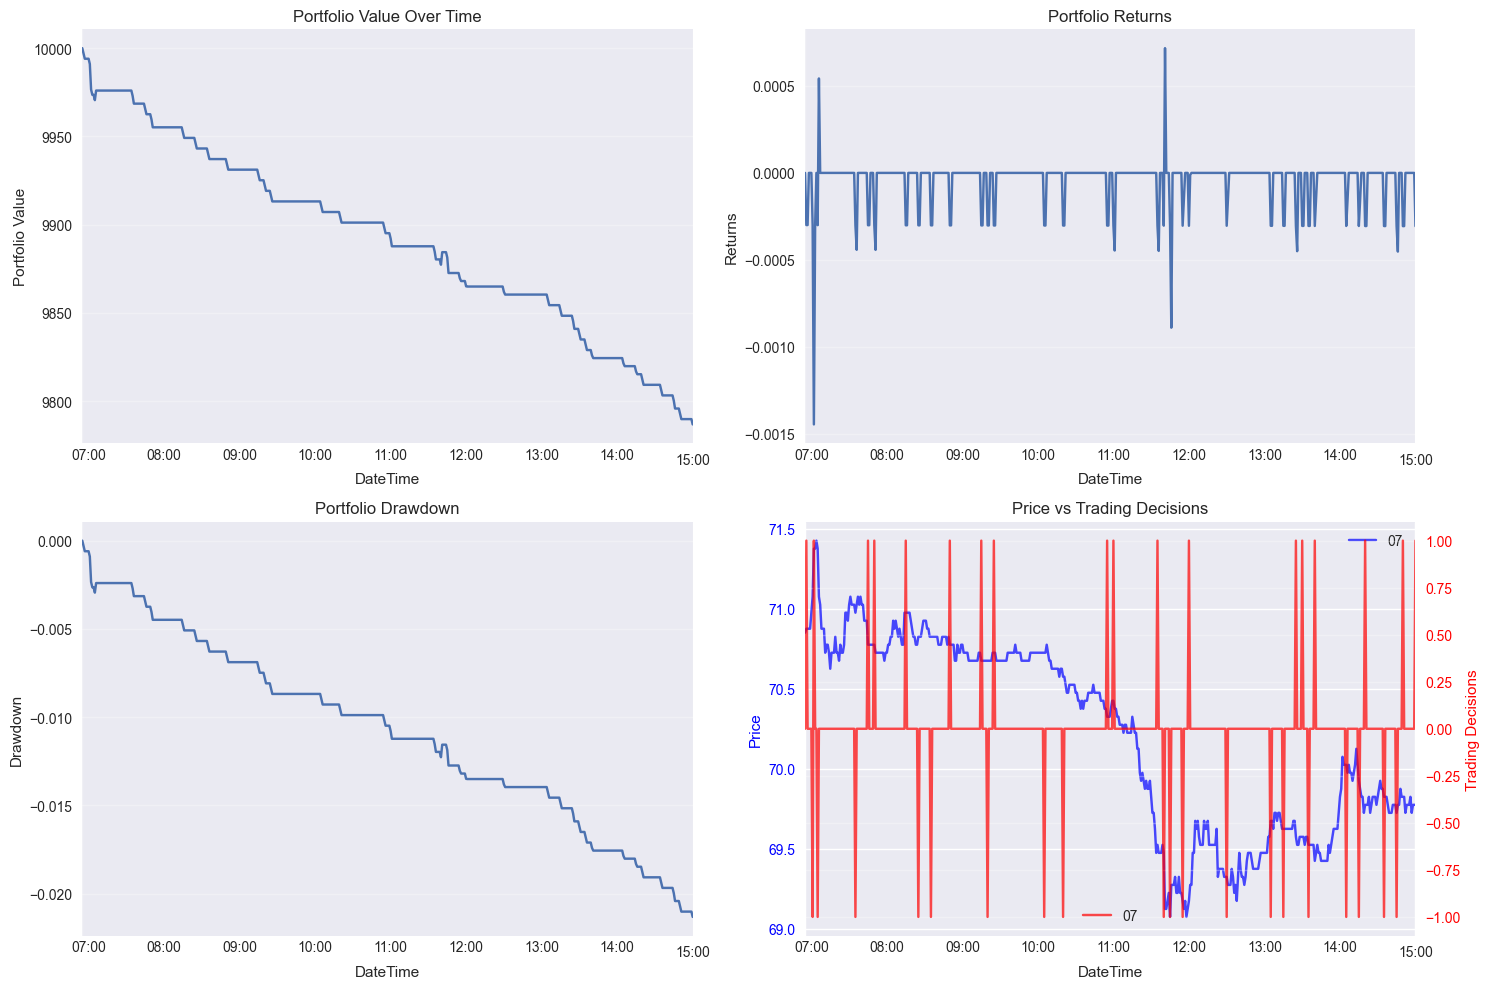

✅ Portfolio görselleştirmesi tamamlandı!


In [7]:
# Portfolio görselleştirmesi
print("📊 Portfolio görselleştirmesi oluşturuluyor...")
analyzer.plot_portfolio()

print("✅ Portfolio görselleştirmesi tamamlandı!")

## 8. Farklı Stratejilerle Karşılaştırma

In [8]:
# Farklı stratejileri test et
strategies = ['momentum', 'mean_reversion', 'random']
strategy_results = {}

print("🔍 Farklı stratejiler test ediliyor...")
print("=" * 60)

for strategy in strategies:
    print(f"\n📊 {strategy.upper()} stratejisi test ediliyor...")
    
    # Portfolio oluştur
    test_portfolio = analyzer.create_portfolio_from_orders(price_data, strategy, init_cash)
    
    # Portfolio'yu analyzer'a set et
    analyzer.portfolio = test_portfolio
    
    # Performans analizi
    test_performance = analyzer.analyze_performance()
    strategy_results[strategy] = test_performance
    
    # Sonuçları yazdır
    print(f"   Toplam Getiri: {test_performance['total_return']:.2%}")
    print(f"   Sharpe Oranı: {test_performance['sharpe_ratio']:.3f}")
    print(f"   Maksimum Drawdown: {test_performance['max_drawdown']:.2%}")
    print(f"   Kazanma Oranı: {test_performance['win_rate']:.2%}")

print("\n✅ Tüm stratejiler test edildi!")

🔍 Farklı stratejiler test ediliyor...

📊 MOMENTUM stratejisi test ediliyor...
🏗️ Creating portfolio with momentum strategy using from_orders...
✅ Portfolio created successfully using from_orders with transaction costs
📊 Analyzing portfolio performance...
   Toplam Getiri: -0.40%
   Sharpe Oranı: -0.132
   Maksimum Drawdown: 0.40%
   Kazanma Oranı: 0.00%

📊 MEAN_REVERSION stratejisi test ediliyor...
🏗️ Creating portfolio with mean_reversion strategy using from_orders...
✅ Portfolio created successfully using from_orders with transaction costs
📊 Analyzing portfolio performance...
   Toplam Getiri: 6.69%
   Sharpe Oranı: 0.035
   Maksimum Drawdown: 8.43%
   Kazanma Oranı: 26.54%

📊 RANDOM stratejisi test ediliyor...
🏗️ Creating portfolio with random strategy using from_orders...
✅ Portfolio created successfully using from_orders with transaction costs
📊 Analyzing portfolio performance...
   Toplam Getiri: -2.13%
   Sharpe Oranı: -0.322
   Maksimum Drawdown: 2.13%
   Kazanma Oranı: 0.41%



## 9. Sonuçları Kaydetme

In [9]:
# Sonuçları kaydet
print("💾 Portfolio sonuçları kaydediliyor...")

# Ana portfolio sonuçları
portfolio_results = {
    'strategy': strategy_type,
    'initial_cash': init_cash,
    'performance': performance,
    'timestamp': datetime.now().isoformat()
}

# Strateji karşılaştırma sonuçları
comparison_results = {
    'strategies': strategy_results,
    'timestamp': datetime.now().isoformat()
}

# JSON dosyalarına kaydet
portfolio_file = os.path.join(results_dir, 'portfolio_analysis.json')
comparison_file = os.path.join(results_dir, 'portfolio_comparison.json')

with open(portfolio_file, 'w', encoding='utf-8') as f:
    json.dump(portfolio_results, f, indent=2, ensure_ascii=False, default=str)

with open(comparison_file, 'w', encoding='utf-8') as f:
    json.dump(comparison_results, f, indent=2, ensure_ascii=False, default=str)

print("✅ Portfolio sonuçları kaydedildi:")
print(f"   Portfolio analizi: {portfolio_file}")
print(f"   Strateji karşılaştırması: {comparison_file}")

print("\n🎉 Portfolio Analizi Tamamlandı!")

💾 Portfolio sonuçları kaydediliyor...
✅ Portfolio sonuçları kaydedildi:
   Portfolio analizi: /Users/tolgacoskun-mac/Source/tlob-training/results/portfolio_analysis.json
   Strateji karşılaştırması: /Users/tolgacoskun-mac/Source/tlob-training/results/portfolio_comparison.json

🎉 Portfolio Analizi Tamamlandı!
